In [1]:
# import required libraries
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input, Flatten, Reshape
from tensorflow.keras.datasets import mnist
from tensorflow.keras import models
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras import layers
from tensorflow.keras import optimizers
from tqdm.keras import TqdmCallback
from matplotlib import pyplot as plt
from IPython import display 
import numpy as np
import gc

I0000 00:00:1788426310.231395      29 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


image shape: (28, 28) and random pixel value is 0.0


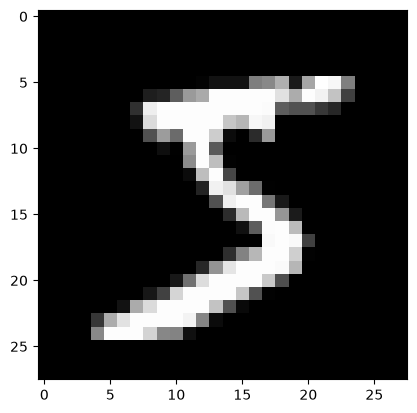

In [2]:
### edTest(test_normalize) ###
# 1. Load the full dataset into temporary variables
(x_train_temp, _), (x_test_temp, _) = mnist.load_data()

# 2. Immediately slice out only what you need (and use .copy() to create a new, smaller array)
sample_size = 1500
x_train = x_train_temp[:sample_size].copy()
x_test = x_test_temp[:sample_size].copy()

# 3. Delete the large temporary arrays from memory
del x_train_temp
del x_test_temp
gc.collect()
# We normalize the pixel data (i.e divide by 255)
x_train = x_train.astype(np.float32) / 255.0
x_test = x_test.astype(np.float32) / 255.0

# We print image dimensions to confirm 
print(f'image shape: {x_train[0].shape} and random pixel value is {x_train[0][10][5]}')

# We also plot example image from x_train
plt.imshow(x_train[0], cmap = "gray")
plt.show()



In [3]:
# Now we create the encoder model to take compress each image down to a lower dimensional latent space.

# pick a size for the latent dimension like 32
latent_size = 32

# Note how sequential models can also be passed a list of layers

# This can be more concise than using add()
model_1 = models.Sequential(name='Encoder')

# Add the input definition of size (28,28)
model_1.add(layers.Input(shape=(28,28)))

# add a flatten layer to convert image of size (28,28) to 784
model_1.add(layers.Flatten())

# add a dense layer with 128 neurons
model_1.add(layers.Dense(128,activation="relu"))

# add another dense layer with 64 neurons
model_1.add(layers.Dense(64,activation="relu"))

# Finally add the last dense layer with latent_size number of neurons
model_1.add(layers.Dense(latent_size))

# Take a quick look at the model summary
model_1.summary()

Model: "Encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,816 (432.88 KB)

 Trainable params: 110,816 (432.88 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# Now we create the decoder model to take compress each image down to a lower dimensional latent space.
model_2 = models.Sequential(name='Decoder')

# Add the input definition of latent_size
model_2.add(layers.Input(shape=(latent_size,)))

# add a dense layer with 64 neurons
model_2.add(layers.Dense(64,activation="relu"))

# add a dense layer with 128 neurons
model_2.add(layers.Dense(128,activation="relu"))

# add a dense layer with 784 neurons and especially choose an appropriate activation function
model_2.add(layers.Dense(784,activation="sigmoid"))

# finally reshape it back to size 28,28
model_2.add(layers.Reshape((28,28)))

# Take a quick look at the model summary
model_2.summary()

Model: "Decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 784)            │       101,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28)         │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,568 (435.81 KB)

 Trainable params: 111,568 (435.81 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# To build autoencoders, we will use the keras 'functional api'
# read more here -> https://www.tensorflow.org/guide/keras/functional

# define an input of the dimension of the image
img = Input(shape=(28,28))

# Use the 'encoder' i.e model_1 from above to get a variable `latent_vector`
latent_vector = model_1(img)

# Use the 'decoder' i.e model_2 from above to get the output variable
output = model_2(latent_vector)


# using functional api to define autoencoder model
autoencoder = Model(inputs = img, outputs = output)

# choose an appropriate loss function for 'reconstruction error'
autoencoder.compile(optimizer='adam',loss='binary_crossentropy')

# Take a quick look at the model summary
autoencoder.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder (Sequential)            │ (None, 32)             │       110,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder (Sequential)            │ (None, 28, 28)         │       111,568 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,384 (868.69 KB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# You can train for 10 epochs to see how well our autoencoder model performs
class SaveReconstructionCallback(tf.keras.callbacks.Callback):
    def __init__(self, x_test_data):
        super().__init__()
        self.x_test = x_test_data
        self.epoch_samples = [] # List to store (original, prediction) pairs

    def on_epoch_end(self, epoch, logs=None):
        # 1. Pick a random image from the test set
        idx = np.random.choice(len(self.x_test))
        orig = self.x_test[idx:idx+1]
        
        # 2. Get reconstruction (using fast functional call)
        recon = self.model(orig, training=False).numpy()
        
        # 3. Save only the numpy arrays (no plotting!)
        self.epoch_samples.append((orig[0], recon[0]))

# --- Usage ---
save_cb = SaveReconstructionCallback(x_test)

autoencoder.fit(
    x=x_train, y=x_train,
    epochs=10, 
    batch_size=32,
    verbose=1,
    callbacks=[save_cb]
)

Epoch 1/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3701
Epoch 2/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2523
Epoch 3/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2267
Epoch 4/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1988
Epoch 5/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1821
Epoch 6/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1718
Epoch 7/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1643
Epoch 8/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1575
Epoch 9/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1518
Epoch 10/10
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1459


                Original        Reconstruction 
---------------------------------------------


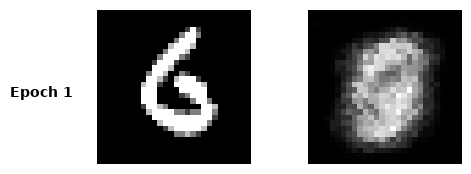

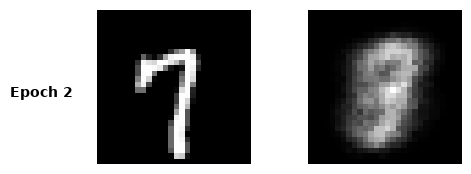

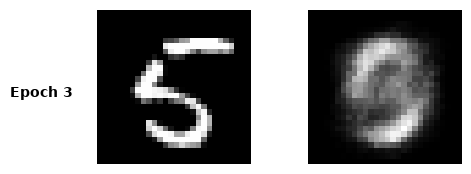

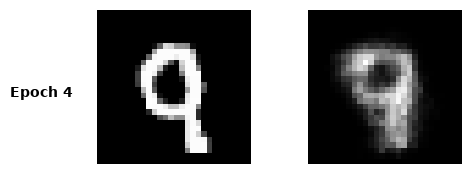

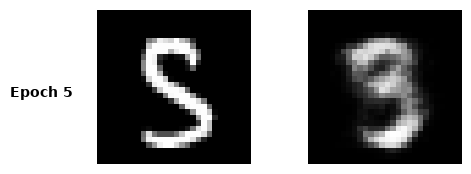

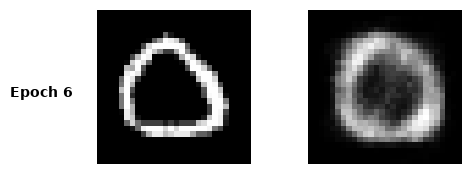

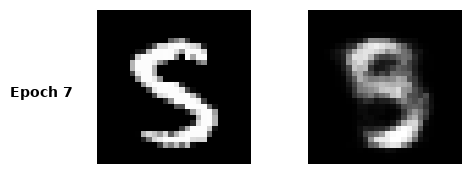

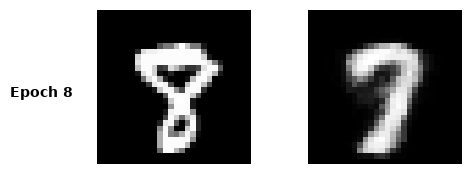

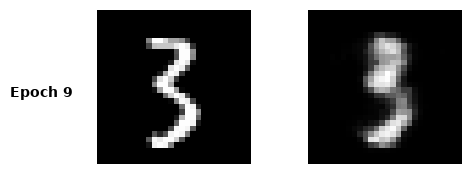

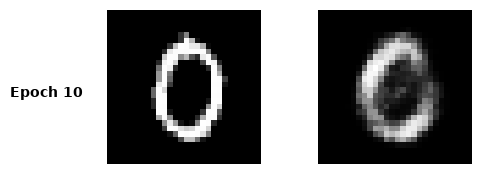

In [7]:
def plot_epoch_history_stable(samples):
    if not samples:
        print("No samples found!")
        return

    print(f"{'':<15} {'Original':<15} {'Reconstruction':<15}")
    print("-" * 45)

    for i, (orig, recon) in enumerate(samples):
        # Create a small, individual figure for each epoch row
        fig, axes = plt.subplots(1, 2, figsize=(5, 2))
        
        # Left: Original
        axes[0].imshow(orig.squeeze(), cmap='gray')
        axes[0].axis('off')
        
        # Right: Reconstruction
        axes[1].imshow(recon.squeeze(), cmap='gray')
        axes[1].axis('off')
        
        # Labels
        plt.suptitle(f"Epoch {i+1}", x=0.1, y=0.5, ha='right', fontsize=10, fontweight='bold')
        
        plt.show()
        
        # Close the figure immediately after showing it
        plt.close(fig)
        
        # cleanup every few epochs
        if i % 3 == 0:
            gc.collect()

# Visualize the history
plot_epoch_history_stable(save_cb.epoch_samples)

## Mindchow 🍲

### Which of the following describes the effect of reducing the latent space dimension to 2?

#### A. The reconstruction quality improves because the model filters out more noise.

#### B. The reconstruction quality becomes worse because the information bottleneck is too tight to capture all essential features.

#### C. The reconstruction quality remains the same as long as the number of epochs is increased.

#### D. The model converges faster and produces sharper images due to the simpler architecture.

In [8]:
### edTest(test_chow1) ###

# Submit an answer choice as a string below 
# (eg. if you choose option A, put 'A')
answer1 = 'B'